In [1]:
from pathlib import Path
import json
import random

import numpy as np
import pandas as pd
from scipy.ndimage import zoom

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt


import matplotlib.pyplot as plt
from IPython.display import display, Markdown



In [ ]:
SCENARIO_NAME = "Test_model_3"  

FOLDER_LEVELS_UP_BEFORE_PREPROCESSING = 2
PREPROCESSING_FOLDER_NAME = "data_preprocessing"
NORMALIZED_DIR_NAME = "Normalized"

COLLECTED_SEGMENTS_PER_SAMPLE = 7
PUBLIC_SEGMENTS_PER_SAMPLE = 2
TARGET_F_BINS = 512
TARGET_T_BINS = 64

BATCH_SIZE = 256
EPOCHS = 200
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4
RANDOM_SEED = 42

NUM_WORKERS = 0

PRELOAD_PREPARED_SAMPLES = True   
PIN_MEMORY = True                  
USE_AMP = True                     
CUDA_BENCHMARK = True              

ANGLE_LOSS_WEIGHT = 1.0
MASS_LOSS_WEIGHT = 1.0

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
USE_AMP = bool(USE_AMP and DEVICE == "cuda")
PIN_MEMORY = bool(PIN_MEMORY and DEVICE == "cuda")

if DEVICE == "cuda" and CUDA_BENCHMARK:
    torch.backends.cudnn.benchmark = True

PREPROCESSING_BASE_DIR = Path.cwd()
for _ in range(FOLDER_LEVELS_UP_BEFORE_PREPROCESSING):
    PREPROCESSING_BASE_DIR = PREPROCESSING_BASE_DIR.parent

PREPROCESSING_ROOT = PREPROCESSING_BASE_DIR / PREPROCESSING_FOLDER_NAME
MODEL_ROOT = Path.cwd() / "Models" / SCENARIO_NAME

print("DEVICE:", DEVICE)
print("PREPROCESSING_ROOT:", PREPROCESSING_ROOT)
print("MODEL_ROOT:", MODEL_ROOT)
print("NUM_WORKERS:", NUM_WORKERS)
print("PRELOAD_PREPARED_SAMPLES:", PRELOAD_PREPARED_SAMPLES)
print("PIN_MEMORY:", PIN_MEMORY)
print("USE_AMP:", USE_AMP)
print("CUDA_BENCHMARK:", CUDA_BENCHMARK)


DEVICE: cuda
PREPROCESSING_ROOT: c:\Users\szymo\Desktop\Wibracje\data_preprocessing
MODEL_ROOT: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train
NUM_WORKERS: 0
PRELOAD_PREPARED_SAMPLES: True
PIN_MEMORY: True
USE_AMP: True
CUDA_BENCHMARK: True


In [3]:
def set_seed(seed=RANDOM_SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


set_seed()


def load_npy(path):
    return np.load(path, allow_pickle=True).item()


def segments_for_dataset(dataset_name):
    if dataset_name == "collected":
        return int(COLLECTED_SEGMENTS_PER_SAMPLE)
    if dataset_name == "public":
        return int(PUBLIC_SEGMENTS_PER_SAMPLE)
    return 1


def view_for_task(task):
    if task in {"angle", "both"}:
        return "tacho"
    if task == "mass":
        return "non_tacho"
    raise ValueError("task must be 'angle', 'mass', or 'both'.")


def output_dim_for_task(task):
    return {"angle": 2, "mass": 1, "both": 3}[task]


def resize_segment(X):
    X = np.asarray(X, dtype=np.float32)
    if X.shape[1:] == (TARGET_F_BINS, TARGET_T_BINS):
        return X
    resized = np.empty((X.shape[0], TARGET_F_BINS, TARGET_T_BINS), dtype=np.float32)
    for c in range(X.shape[0]):
        factors = (TARGET_F_BINS / X.shape[1], TARGET_T_BINS / X.shape[2])
        resized[c] = zoom(X[c], factors, order=1).astype(np.float32)
    return resized


def model_output_dirs(model_name):
    weights_dir = MODEL_ROOT / "weight" / model_name
    additional_data_dir = MODEL_ROOT / "additional_data" / model_name
    weights_dir.mkdir(parents=True, exist_ok=True)
    additional_data_dir.mkdir(parents=True, exist_ok=True)
    return weights_dir, additional_data_dir

In [ ]:
def collect_files(task, split, datasets):
    view = view_for_task(task)
    files = []
    for dataset_name in datasets:
        folder = PREPROCESSING_ROOT / dataset_name / NORMALIZED_DIR_NAME / view / split
        if folder.exists():
            files.extend(sorted(folder.glob("*.npy")))
    return files


class VibrationRegressionDataset(Dataset):


    def __init__(self, files, task, preload=PRELOAD_PREPARED_SAMPLES):
        self.files = [Path(p) for p in files]
        self.task = task
        self.preload = bool(preload)
        self.index = []
        self.samples = []
        self.total_x_bytes = 0
        self.total_y_bytes = 0

        if self.preload:
            self._preload_samples()
        else:
            self._build_lazy_index()

    def _build_target(self, labels):
        angle = np.asarray(labels["angle_sin_cos"], dtype=np.float32)
        mass = np.array([labels["imbalance_relative"]], dtype=np.float32)

        if self.task == "angle":
            return angle
        if self.task == "mass":
            return mass
        return np.concatenate([angle, mass]).astype(np.float32)

    def _build_meta(self, path, payload, segment_idx):
        labels = payload["labels"]
        metadata = payload["metadata"]
        return {
            "path": str(path),
            "dataset": metadata["dataset"],
            "source_file": metadata["source_file"],
            "segment_idx": int(segment_idx),
            "imbalance_actual_gmm": float(labels["imbalance_actual_gmm"]),
            "imbalance_relative": float(labels["imbalance_relative"]),
            "angle_deg": float(labels["angle_deg"]),
        }

    def _segment_bounds(self, X, n_segments, segment_idx):
        t_bins = int(X.shape[-1])
        segment_len = t_bins // int(n_segments)
        if segment_len <= 0:
            raise ValueError(
                f"Cannot split array with {t_bins} time bins into {n_segments} segments."
            )
        start = int(segment_idx * segment_len)
        stop = int(start + segment_len)
        return start, stop

    def _prepare_segment(self, X, segment_idx, n_segments):
        start, stop = self._segment_bounds(X, n_segments, segment_idx)
        X_seg = resize_segment(X[:, :, start:stop])
        return np.ascontiguousarray(X_seg, dtype=np.float32)

    def _build_lazy_index(self):
        for file_idx, path in enumerate(self.files):
            payload = load_npy(path)
            dataset_name = payload["metadata"]["dataset"]
            n_segments = segments_for_dataset(dataset_name)
            for segment_idx in range(n_segments):
                self.index.append((file_idx, segment_idx, n_segments))

    def _preload_samples(self):
        print(f"Preloading and resizing {len(self.files)} files for task='{self.task}'...")

        for file_idx, path in enumerate(self.files, start=1):
            payload = load_npy(path)
            X = np.asarray(payload["X"], dtype=np.float32)
            labels = payload["labels"]
            dataset_name = payload["metadata"]["dataset"]
            n_segments = segments_for_dataset(dataset_name)
            y = np.ascontiguousarray(self._build_target(labels), dtype=np.float32)

            for segment_idx in range(n_segments):
                X_seg = self._prepare_segment(X, segment_idx, n_segments)
                y_seg = y.copy()
                meta = self._build_meta(path, payload, segment_idx)
                self.samples.append({"X": X_seg, "y": y_seg, "meta": meta})
                self.total_x_bytes += X_seg.nbytes
                self.total_y_bytes += y_seg.nbytes

            if file_idx % 25 == 0 or file_idx == len(self.files):
                gb = (self.total_x_bytes + self.total_y_bytes) / (1024 ** 3)
                print(f"  {file_idx}/{len(self.files)} loaded")

        if len(self.files) == 0:
            print("  no files found for this dataset/scope/split")

    def __len__(self):
        return len(self.samples) if self.preload else len(self.index)

    def __getitem__(self, idx):
        if self.preload:
            sample = self.samples[idx]
            return {
                "X": torch.from_numpy(sample["X"]),
                "y": torch.from_numpy(sample["y"]),
                "meta": sample["meta"],
            }

        file_idx, segment_idx, n_segments = self.index[idx]
        path = self.files[file_idx]
        payload = load_npy(path)
        X = np.asarray(payload["X"], dtype=np.float32)
        X_seg = self._prepare_segment(X, segment_idx, n_segments)
        y = np.ascontiguousarray(self._build_target(payload["labels"]), dtype=np.float32)
        meta = self._build_meta(path, payload, segment_idx)

        return {
            "X": torch.from_numpy(X_seg),
            "y": torch.from_numpy(y),
            "meta": meta,
        }


def make_loaders(task, datasets):
    train_files = collect_files(task, "train", datasets)
    test_files = collect_files(task, "test", datasets)

    train_ds = VibrationRegressionDataset(train_files, task, preload=PRELOAD_PREPARED_SAMPLES)
    test_ds = VibrationRegressionDataset(test_files, task, preload=PRELOAD_PREPARED_SAMPLES)

    loader_kwargs = {
        "batch_size": BATCH_SIZE,
        "num_workers": NUM_WORKERS,
        "pin_memory": PIN_MEMORY,
    }

    if NUM_WORKERS > 0:
        loader_kwargs["persistent_workers"] = True
        loader_kwargs["prefetch_factor"] = 4

    train_loader = DataLoader(
        train_ds,
        shuffle=True,
        drop_last=False,
        **loader_kwargs,
    )
    test_loader = DataLoader(
        test_ds,
        shuffle=False,
        drop_last=False,
        **loader_kwargs,
    )
    return train_files, test_files, train_ds, test_ds, train_loader, test_loader


In [5]:
class SimpleSpectrogramCNN(nn.Module):
    def __init__(self, in_channels, out_dim):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(in_channels, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.AdaptiveAvgPool2d((1, 1)),
        )
        self.regressor = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128, 64),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(64, 32),
            nn.ReLU(inplace=True),
            nn.Dropout(0.2),
            nn.Linear(32, out_dim),
        )

    def forward(self, x):
        return self.regressor(self.features(x))


def normalize_sincos(x, eps=1e-8):
    return x / torch.linalg.norm(x, dim=1, keepdim=True).clamp_min(eps)


def task_loss(pred, target, task):
    mse = nn.functional.mse_loss
    if task == "angle":
        return mse(normalize_sincos(pred), target)
    if task == "mass":
        return mse(pred, target)
    angle_loss = mse(normalize_sincos(pred[:, :2]), target[:, :2])
    mass_loss = mse(pred[:, 2:3], target[:, 2:3])
    return ANGLE_LOSS_WEIGHT * angle_loss + MASS_LOSS_WEIGHT * mass_loss


def angle_deg_from_sincos(x):
    sin_v = x[:, 0]
    cos_v = x[:, 1]
    return (np.degrees(np.arctan2(sin_v, cos_v)) + 360) % 360


def circular_mae_deg(pred_sincos, true_sincos):
    pred_deg = angle_deg_from_sincos(pred_sincos)
    true_deg = angle_deg_from_sincos(true_sincos)
    diff = (pred_deg - true_deg + 180) % 360 - 180
    return float(np.mean(np.abs(diff)))

In [6]:
def make_amp_scaler():
    if not USE_AMP:
        return None
    try:
        return torch.amp.GradScaler("cuda", enabled=True)
    except Exception:
        return torch.cuda.amp.GradScaler(enabled=True)


def autocast_if_enabled():
    if USE_AMP:
        try:
            return torch.amp.autocast("cuda", dtype=torch.float16, enabled=True)
        except Exception:
            return torch.cuda.amp.autocast(dtype=torch.float16, enabled=True)

    class _NoAutocast:
        def __enter__(self):
            return None
        def __exit__(self, exc_type, exc_value, traceback):
            return False

    return _NoAutocast()


def train_one_epoch(model, loader, optimizer, task, scaler=None):
    model.train()
    losses = []

    for batch in loader:
        X = batch["X"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)
        y = batch["y"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)

        optimizer.zero_grad(set_to_none=True)

        with autocast_if_enabled():
            pred = model(X)
            loss = task_loss(pred, y, task)

        if USE_AMP and scaler is not None:
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            loss.backward()
            optimizer.step()

        losses.append(float(loss.detach().cpu()))

    return float(np.mean(losses)) if losses else np.nan


def unpack_batch_meta(batch_meta):
    """Convert PyTorch DataLoader-collated metadata back to one dict per sample."""
    if isinstance(batch_meta, dict):
        first_value = next(iter(batch_meta.values()), [])
        batch_size = len(first_value)
        rows = []
        for i in range(batch_size):
            row = {}
            for key, value in batch_meta.items():
                item = value[i]
                if torch.is_tensor(item):
                    item = item.item() if item.ndim == 0 else item.detach().cpu().tolist()
                elif isinstance(item, np.generic):
                    item = item.item()
                row[key] = item
            rows.append(row)
        return rows
    return list(batch_meta)


@torch.no_grad()
def evaluate(model, loader, task):
    model.eval()
    losses = []
    preds = []
    targets = []
    metas = []

    for batch in loader:
        X = batch["X"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)
        y = batch["y"].to(DEVICE, dtype=torch.float32, non_blocking=PIN_MEMORY)

        with autocast_if_enabled():
            pred = model(X)
            loss = task_loss(pred, y, task)

        losses.append(float(loss.detach().cpu()))
        preds.append(pred.detach().float().cpu().numpy())
        targets.append(y.detach().cpu().numpy())
        metas.extend(unpack_batch_meta(batch["meta"]))

    if preds:
        pred = np.concatenate(preds, axis=0)
        target = np.concatenate(targets, axis=0)
    else:
        pred = np.empty((0, output_dim_for_task(task)), dtype=np.float32)
        target = np.empty_like(pred)

    metrics = {"loss": float(np.mean(losses)) if losses else np.nan}
    if task in {"angle", "both"} and len(pred):
        pred_angle = pred[:, :2]
        pred_angle = pred_angle / np.maximum(np.linalg.norm(pred_angle, axis=1, keepdims=True), 1e-8)
        metrics["angle_mae_deg"] = circular_mae_deg(pred_angle, target[:, :2])
    if task == "mass" and len(pred):
        metrics["mass_mae_relative"] = float(np.mean(np.abs(pred[:, 0] - target[:, 0])))
    if task == "both" and len(pred):
        metrics["mass_mae_relative"] = float(np.mean(np.abs(pred[:, 2] - target[:, 2])))
    return metrics, pred, target, metas


def save_predictions(task, pred, target, metas, additional_data_dir):
    rows = []
    for i, meta in enumerate(metas):
        row = dict(meta)
        if task in {"angle", "both"}:
            pred_angle = pred[i, :2]
            pred_angle = pred_angle / max(np.linalg.norm(pred_angle), 1e-8)
            row["angle_pred_deg"] = float(angle_deg_from_sincos(pred_angle.reshape(1, -1))[0])
            row["angle_true_deg"] = float(meta["angle_deg"])
        if task == "mass":
            row["imbalance_relative_pred"] = float(pred[i, 0])
            row["imbalance_relative_true"] = float(target[i, 0])
        if task == "both":
            row["imbalance_relative_pred"] = float(pred[i, 2])
            row["imbalance_relative_true"] = float(target[i, 2])
        rows.append(row)
    df = pd.DataFrame(rows)
    df.to_csv(additional_data_dir / "predictions.csv", index=False)
    return df


In [ ]:
def model_plot_title(model_name, scope, datasets):
    """Human-readable title for the training curve shown below each model cell."""
    dataset_label = " + ".join(str(d).capitalize() for d in datasets)
    if scope == "angle":
        return f"{dataset_label} dataset -> angle sin/cos regression"
    if scope == "mass":
        return f"{dataset_label} dataset -> imbalance/mass regression"
    if scope == "both":
        return f"{dataset_label} dataset -> angle + mass regression"
    return str(model_name)


def plot_training_loss_curve(history, title):
    """Show the train/test loss curve immediately after a model finishes training."""
    if history is None or len(history) == 0:
        print(f"No training history to plot for: {title}")
        return

    history = pd.DataFrame(history).copy()
    required = {"epoch", "train_loss"}
    missing = required.difference(history.columns)
    if missing:
        print(f"Cannot plot training loss for {title}; missing columns: {sorted(missing)}")
        return

    with plt.style.context("dark_background"):
        fig, ax = plt.subplots(figsize=(10.5, 4.0))
        ax.plot(history["epoch"], history["train_loss"], label="train loss")
        if "val_loss" in history.columns:
            ax.plot(history["epoch"], history["val_loss"], label="test loss")
        ax.set_xlabel("Epoch")
        ax.set_ylabel("MSE loss")
        ax.set_title(f"{title} | loss")
        ax.legend(loc="best")
        plt.tight_layout()
        plt.show()


def _json_safe(value):
    """Convert numpy/pandas/path values into JSON-serializable Python values."""
    if isinstance(value, dict):
        return {str(k): _json_safe(v) for k, v in value.items()}
    if isinstance(value, (list, tuple)):
        return [_json_safe(v) for v in value]
    if isinstance(value, pd.DataFrame):
        return _json_safe(value.to_dict(orient="records"))
    if isinstance(value, pd.Series):
        return _json_safe(value.to_dict())
    if isinstance(value, Path):
        return str(value)
    if isinstance(value, np.ndarray):
        return _json_safe(value.tolist())
    if isinstance(value, np.generic):
        return _json_safe(value.item())
    if isinstance(value, float) and (np.isnan(value) or np.isinf(value)):
        return None
    return value


def build_metrics_payload(model_name, scope, datasets, metrics, history_df, run_config):
    """Create a single JSON payload containing final metrics and full training history."""
    history_df = pd.DataFrame(history_df).copy()
    history_records = _json_safe(history_df.to_dict(orient="records"))

    best_epoch = None
    best_epoch_metrics = {}
    if len(history_df) and "val_loss" in history_df.columns:
        val_loss = pd.to_numeric(history_df["val_loss"], errors="coerce")
        if val_loss.notna().any():
            best_idx = int(val_loss.idxmin())
            best_epoch_metrics = _json_safe(history_df.loc[best_idx].to_dict())
            if "epoch" in history_df.columns:
                best_epoch = int(history_df.loc[best_idx, "epoch"])

    payload = {
        "model_name": model_name,
        "scope": scope,
        "datasets": list(datasets),
        "scenario_name": SCENARIO_NAME,
        "final_metrics": _json_safe(metrics),
        "best_epoch": best_epoch,
        "best_epoch_metrics": best_epoch_metrics,
        "training_history": history_records,
        "history": history_records,  
        "history_columns": list(history_df.columns),
        "run_config": _json_safe(run_config),
    }

    payload.update(_json_safe(metrics))
    return payload


def save_metrics_artifacts(model_name, scope, datasets, metrics, history_df, run_config, additional_data_dir):
    """Save expanded metrics/history artifacts for model comparison notebooks."""
    additional_data_dir = Path(additional_data_dir)
    additional_data_dir.mkdir(parents=True, exist_ok=True)

    payload = build_metrics_payload(
        model_name=model_name,
        scope=scope,
        datasets=datasets,
        metrics=metrics,
        history_df=history_df,
        run_config=run_config,
    )

    with open(additional_data_dir / "metrics.json", "w", encoding="utf-8") as f:
        json.dump(payload, f, indent=2, ensure_ascii=False)

    history_df = pd.DataFrame(history_df).copy()
    if len(history_df):
        history_long = history_df.melt(
            id_vars=["epoch"],
            var_name="metric",
            value_name="value",
        )
        history_long.insert(0, "scenario_name", SCENARIO_NAME)
        history_long.insert(1, "model_name", model_name)
        history_long.insert(2, "scope", scope)
        history_long.to_csv(additional_data_dir / "history_long.csv", index=False)

    metric_rows = []
    for metric_name, metric_value in dict(metrics).items():
        if isinstance(metric_value, (int, float, np.integer, np.floating)):
            metric_rows.append({
                "scenario_name": SCENARIO_NAME,
                "model_name": model_name,
                "scope": scope,
                "metric": metric_name,
                "value": float(metric_value),
                "source": "final_best_model",
            })

    best_epoch_metrics = payload.get("best_epoch_metrics", {}) or {}
    for metric_name, metric_value in best_epoch_metrics.items():
        if metric_name == "epoch":
            continue
        if isinstance(metric_value, (int, float, np.integer, np.floating)):
            metric_rows.append({
                "scenario_name": SCENARIO_NAME,
                "model_name": model_name,
                "scope": scope,
                "metric": f"best_epoch_{metric_name}",
                "value": float(metric_value),
                "source": "best_epoch_history",
            })

    main_metrics_df = pd.DataFrame(metric_rows)
    main_metrics_df.to_csv(additional_data_dir / "main_metrics.csv", index=False)
    return payload, main_metrics_df


def train_model(model_name, scope, datasets):

    set_seed()
    weights_dir, additional_data_dir = model_output_dirs(model_name)
    train_files, test_files, train_ds, test_ds, train_loader, test_loader = make_loaders(scope, datasets)

    print(f"MODEL_NAME: {model_name}")
    print(f"SCOPE: {scope}")
    print(f"DATASETS: {datasets}")
    print(f"train files/segments: {len(train_files)}/{len(train_ds)}")
    print(f"test files/segments:  {len(test_files)}/{len(test_ds)}")
    print(f"weights dir: {weights_dir}")
    print(f"additional data dir: {additional_data_dir}")

    example = train_ds[0]
    in_channels = int(example["X"].shape[0])
    model = SimpleSpectrogramCNN(in_channels=in_channels, out_dim=output_dim_for_task(scope)).to(DEVICE)
    optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
    scaler = make_amp_scaler()

    best_loss = float("inf")
    history = []
    for epoch in range(1, EPOCHS + 1):
        train_loss = train_one_epoch(model, train_loader, optimizer, scope, scaler=scaler)
        val_metrics, _, _, _ = evaluate(model, test_loader, scope)
        row = {"epoch": epoch, "train_loss": train_loss, **{f"val_{k}": v for k, v in val_metrics.items()}}
        history.append(row)
        print(row)

        torch.save(model.state_dict(), weights_dir / "last.pt")
        if val_metrics["loss"] < best_loss:
            best_loss = val_metrics["loss"]
            torch.save(model.state_dict(), weights_dir / "best.pt")

    history_df = pd.DataFrame(history)
    history_df.to_csv(additional_data_dir / "history.csv", index=False)

    model.load_state_dict(torch.load(weights_dir / "best.pt", map_location=DEVICE))
    metrics, pred, target, metas = evaluate(model, test_loader, scope)
    predictions_df = save_predictions(scope, pred, target, metas, additional_data_dir)

    run_config = {
        "model_name": model_name,
        "scope": scope,
        "datasets": list(datasets),
        "scenario_name": SCENARIO_NAME,
        "preprocessing_root": str(PREPROCESSING_ROOT),
        "model_root": str(MODEL_ROOT),
        "weights_dir": str(weights_dir),
        "additional_data_dir": str(additional_data_dir),
        "batch_size": BATCH_SIZE,
        "epochs": EPOCHS,
        "learning_rate": LEARNING_RATE,
        "weight_decay": WEIGHT_DECAY,
        "random_seed": RANDOM_SEED,
        "num_workers": NUM_WORKERS,
        "preload_prepared_samples": PRELOAD_PREPARED_SAMPLES,
        "pin_memory": PIN_MEMORY,
        "use_amp": USE_AMP,
        "cuda_benchmark": CUDA_BENCHMARK,
        "device": DEVICE,
    }
    with open(additional_data_dir / "run_config.json", "w", encoding="utf-8") as f:
        json.dump(run_config, f, indent=2, ensure_ascii=False)

    metrics_payload, main_metrics_df = save_metrics_artifacts(
        model_name=model_name,
        scope=scope,
        datasets=datasets,
        metrics=metrics,
        history_df=history_df,
        run_config=run_config,
        additional_data_dir=additional_data_dir,
    )

    print("Final metrics:", metrics)
    print("Saved expanded metrics:", additional_data_dir / "metrics.json")
    print("Saved main metrics table:", additional_data_dir / "main_metrics.csv")

    plot_training_loss_curve(
        history_df,
        model_plot_title(model_name=model_name, scope=scope, datasets=datasets),
    )

    return model, history_df, metrics, predictions_df


## Train angle model — collected data

Preloading and resizing 308 files for task='angle'...
  25/308 loaded
  50/308 loaded
  75/308 loaded
  100/308 loaded
  125/308 loaded
  150/308 loaded
  175/308 loaded
  200/308 loaded
  225/308 loaded
  250/308 loaded
  275/308 loaded
  300/308 loaded
  308/308 loaded
Preloading and resizing 81 files for task='angle'...
  25/81 loaded
  50/81 loaded
  75/81 loaded
  81/81 loaded
MODEL_NAME: angle_collected
SCOPE: angle
DATASETS: ['collected']
train files/segments: 308/2156
test files/segments:  81/567
weights dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\weight\angle_collected
additional data dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\additional_data\angle_collected
{'epoch': 1, 'train_loss': 0.7585220403141446, 'val_loss': 0.8128790458043417, 'val_angle_mae_deg': 74.36368560791016}
{'epoch': 2, 'trai

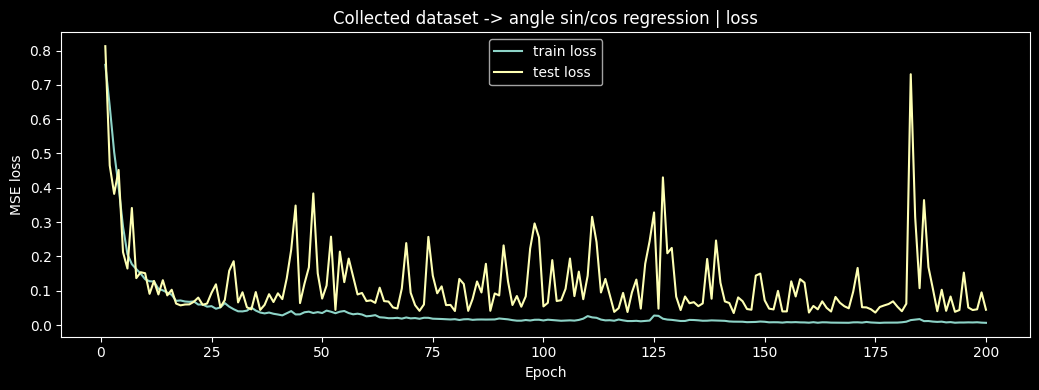

In [8]:
# =============================================================================
# TRAINING CONFIGURATION: angle, collected data
# =============================================================================
MODEL_NAME = "angle_collected"
SCOPE = "angle"
DATASETS = ["collected"]

angle_collected_model, angle_collected_history, angle_collected_metrics, angle_collected_predictions = train_model(
    model_name=MODEL_NAME,
    scope=SCOPE,
    datasets=DATASETS,
)

## Train mass model — collected data

Preloading and resizing 462 files for task='mass'...
  25/462 loaded
  50/462 loaded
  75/462 loaded
  100/462 loaded
  125/462 loaded
  150/462 loaded
  175/462 loaded
  200/462 loaded
  225/462 loaded
  250/462 loaded
  275/462 loaded
  300/462 loaded
  325/462 loaded
  350/462 loaded
  375/462 loaded
  400/462 loaded
  425/462 loaded
  450/462 loaded
  462/462 loaded
Preloading and resizing 123 files for task='mass'...
  25/123 loaded
  50/123 loaded
  75/123 loaded
  100/123 loaded
  123/123 loaded
MODEL_NAME: mass_collected
SCOPE: mass
DATASETS: ['collected']
train files/segments: 462/3234
test files/segments:  123/861
weights dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\weight\mass_collected
additional data dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\additional_data\mass_collected
{'epoch': 1, 'tra

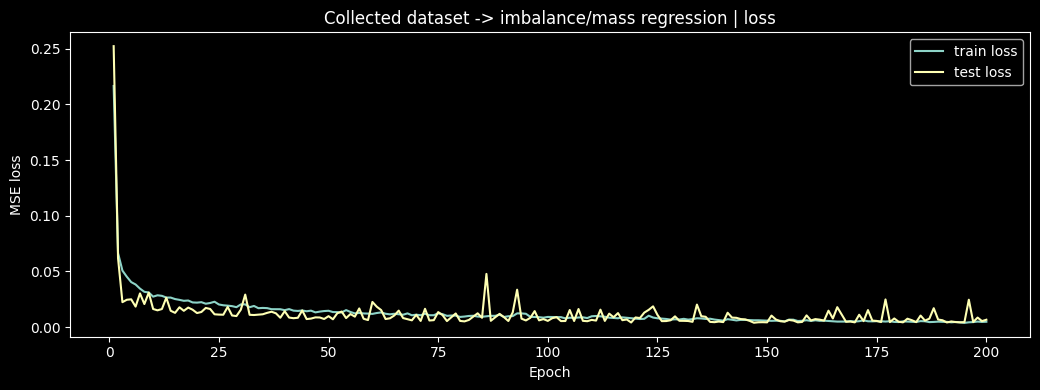

In [9]:
# =============================================================================
# TRAINING CONFIGURATION: mass, collected data
# =============================================================================
MODEL_NAME = "mass_collected"
SCOPE = "mass"
DATASETS = ["collected"]

mass_collected_model, mass_collected_history, mass_collected_metrics, mass_collected_predictions = train_model(
    model_name=MODEL_NAME,
    scope=SCOPE,
    datasets=DATASETS,
)

## Train mass model — public data

Preloading and resizing 305 files for task='mass'...
  25/305 loaded
  50/305 loaded
  75/305 loaded
  100/305 loaded
  125/305 loaded
  150/305 loaded
  175/305 loaded
  200/305 loaded
  225/305 loaded
  250/305 loaded
  275/305 loaded
  300/305 loaded
  305/305 loaded
Preloading and resizing 77 files for task='mass'...
  25/77 loaded
  50/77 loaded
  75/77 loaded
  77/77 loaded
MODEL_NAME: mass_public
SCOPE: mass
DATASETS: ['public']
train files/segments: 305/610
test files/segments:  77/154
weights dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\weight\mass_public
additional data dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\additional_data\mass_public
{'epoch': 1, 'train_loss': 0.37260661522547406, 'val_loss': 0.4185001850128174, 'val_mass_mae_relative': 0.5617801547050476}
{'epoch': 2, 'train_loss': 0.20

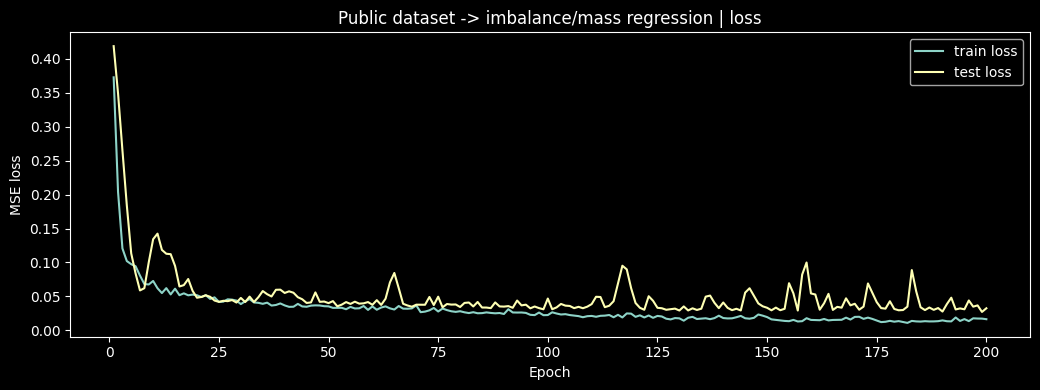

In [10]:
# =============================================================================
# TRAINING CONFIGURATION: mass, public data
# =============================================================================
MODEL_NAME = "mass_public"
SCOPE = "mass"
DATASETS = ["public"]

mass_public_model, mass_public_history, mass_public_metrics, mass_public_predictions = train_model(
    model_name=MODEL_NAME,
    scope=SCOPE,
    datasets=DATASETS,
)

## Train combined angle + mass model — collected data

Preloading and resizing 308 files for task='both'...
  25/308 loaded
  50/308 loaded
  75/308 loaded
  100/308 loaded
  125/308 loaded
  150/308 loaded
  175/308 loaded
  200/308 loaded
  225/308 loaded
  250/308 loaded
  275/308 loaded
  300/308 loaded
  308/308 loaded
Preloading and resizing 81 files for task='both'...
  25/81 loaded
  50/81 loaded
  75/81 loaded
  81/81 loaded
MODEL_NAME: angle_mass_collected
SCOPE: both
DATASETS: ['collected']
train files/segments: 308/2156
test files/segments:  81/567
weights dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\weight\angle_mass_collected
additional data dir: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\additional_data\angle_mass_collected
{'epoch': 1, 'train_loss': 1.274276852607727, 'val_loss': 1.277089238166809, 'val_angle_mae_deg': 91.03882598876953, 'val_mas

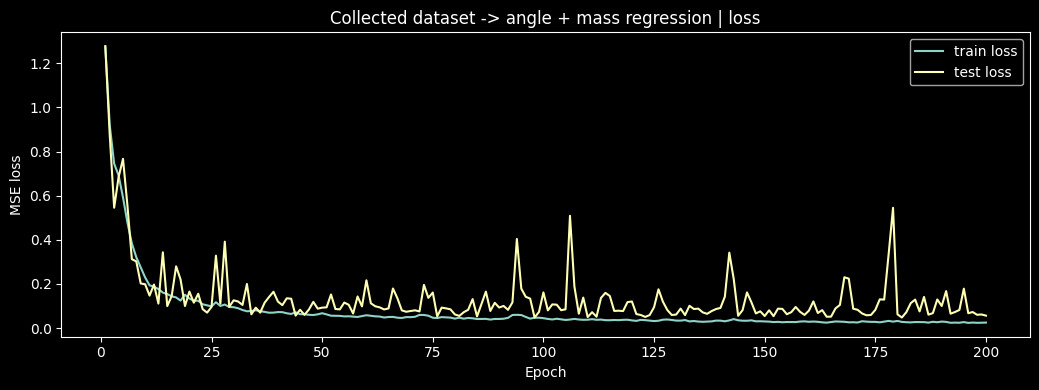

In [11]:
# =============================================================================
# TRAINING CONFIGURATION: angle + mass, collected data
# =============================================================================
MODEL_NAME = "angle_mass_collected"
SCOPE = "both"
DATASETS = ["collected"]

angle_mass_collected_model, angle_mass_collected_history, angle_mass_collected_metrics, angle_mass_collected_predictions = train_model(
    model_name=MODEL_NAME,
    scope=SCOPE,
    datasets=DATASETS,
)

In [ ]:
def load_label_scaling(dataset_name):
    path = PREPROCESSING_ROOT / dataset_name / "label_scaling.json"
    with open(path, "r", encoding="utf-8") as f:
        return json.load(f)


def imbalance_relative_to_actual_gmm(relative_value, dataset_name):
    scaling = load_label_scaling(dataset_name)
    min_v = float(scaling["dataset_min_gmm"])
    max_v = float(scaling["dataset_max_gmm"])
    return float(relative_value) * (max_v - min_v) + min_v


def imbalance_actual_gmm_to_relative(actual_gmm, dataset_name):
    scaling = load_label_scaling(dataset_name)
    min_v = float(scaling["dataset_min_gmm"])
    max_v = float(scaling["dataset_max_gmm"])
    if np.isclose(max_v, min_v):
        return 0.0
    return float((actual_gmm - min_v) / (max_v - min_v))



### Final grading

In [ ]:

def _load_saved_metrics(model_name):
    metrics_path = MODEL_ROOT / "additional_data" / model_name / "metrics.json"
    if metrics_path.exists():
        with open(metrics_path, "r", encoding="utf-8") as f:
            return json.load(f)
    return {}


def _load_saved_predictions(model_name):
    pred_path = MODEL_ROOT / "additional_data" / model_name / "predictions.csv"
    if pred_path.exists():
        return pd.read_csv(pred_path)
    return None


def _safe_relative_to_actual_gmm(relative_value, dataset_name):
    try:
        return imbalance_relative_to_actual_gmm(float(relative_value), str(dataset_name))
    except Exception:
        return np.nan


def _circular_abs_error_deg(true_deg, pred_deg):
    true_deg = np.asarray(true_deg, dtype=float)
    pred_deg = np.asarray(pred_deg, dtype=float)
    diff = (pred_deg - true_deg + 180.0) % 360.0 - 180.0
    return np.abs(diff)


def _non_nan(values):
    arr = np.asarray(values, dtype=float)
    return arr[~np.isnan(arr)]


def _series_metric_rows(model_name, metric_name, values, unit):
    arr = _non_nan(values)
    if len(arr) == 0:
        return []
    return [
        {"model": model_name, "metric": f"{metric_name}_mean", "value": float(np.mean(arr)), "unit": unit},
        {"model": model_name, "metric": f"{metric_name}_median", "value": float(np.median(arr)), "unit": unit},
        {"model": model_name, "metric": f"{metric_name}_p95", "value": float(np.percentile(arr, 95)), "unit": unit},
        {"model": model_name, "metric": f"{metric_name}_max", "value": float(np.max(arr)), "unit": unit},
    ]


def add_final_error_columns(predictions_df, scope):
    """Return predictions_df with explicit error columns used for final grading."""
    if predictions_df is None:
        return pd.DataFrame()

    df = predictions_df.copy().reset_index(drop=True)
    if "sample_index" not in df.columns:
        df.insert(0, "sample_index", np.arange(len(df)))

    if scope in {"angle", "both"}:
        if "angle_true_deg" in df.columns and "true_angle_deg" not in df.columns:
            df["true_angle_deg"] = df["angle_true_deg"].astype(float)
        if "angle_pred_deg" in df.columns and "pred_angle_deg" not in df.columns:
            df["pred_angle_deg"] = df["angle_pred_deg"].astype(float)

        if {"true_angle_deg", "pred_angle_deg"}.issubset(df.columns):
            df["angle_error_deg"] = _circular_abs_error_deg(df["true_angle_deg"], df["pred_angle_deg"])
            true_rad = np.deg2rad(df["true_angle_deg"].to_numpy(dtype=float))
            pred_rad = np.deg2rad(df["pred_angle_deg"].to_numpy(dtype=float))
            df["true_sin"] = np.sin(true_rad)
            df["true_cos"] = np.cos(true_rad)
            df["pred_sin"] = np.sin(pred_rad)
            df["pred_cos"] = np.cos(pred_rad)

    if scope in {"mass", "both"}:
        if "imbalance_relative_true" in df.columns and "true_value" not in df.columns:
            df["true_value"] = df["imbalance_relative_true"].astype(float)
        if "imbalance_relative_pred" in df.columns and "pred_value" not in df.columns:
            df["pred_value"] = df["imbalance_relative_pred"].astype(float)

        if {"true_value", "pred_value"}.issubset(df.columns):
            df["residual"] = df["pred_value"] - df["true_value"]
            df["abs_error"] = df["residual"].abs()

            if "dataset" in df.columns:
                df["true_actual_gmm_from_relative"] = [
                    _safe_relative_to_actual_gmm(v, d) for v, d in zip(df["true_value"], df["dataset"])
                ]
                df["pred_actual_gmm_from_relative"] = [
                    _safe_relative_to_actual_gmm(v, d) for v, d in zip(df["pred_value"], df["dataset"])
                ]
                df["residual_actual_gmm"] = df["pred_actual_gmm_from_relative"] - df["true_actual_gmm_from_relative"]
                df["abs_error_actual_gmm"] = df["residual_actual_gmm"].abs()

    return df


def build_final_grade(model_name, scope, predictions_df, metrics=None):
    metrics = metrics or {}
    rows = []

    if "loss" in metrics:
        rows.append({"model": model_name, "metric": "test_loss_best_model", "value": float(metrics["loss"]), "unit": "MSE"})
    if "angle_mae_deg" in metrics:
        rows.append({"model": model_name, "metric": "test_angle_mae_from_evaluate", "value": float(metrics["angle_mae_deg"]), "unit": "deg"})
    if "mass_mae_relative" in metrics:
        rows.append({"model": model_name, "metric": "test_mass_mae_from_evaluate", "value": float(metrics["mass_mae_relative"]), "unit": "relative"})

    if scope in {"angle", "both"} and "angle_error_deg" in predictions_df.columns:
        rows.extend(_series_metric_rows(model_name, "angle_abs_error", predictions_df["angle_error_deg"], "deg"))

    if scope in {"mass", "both"} and "abs_error" in predictions_df.columns:
        rows.extend(_series_metric_rows(model_name, "mass_abs_error", predictions_df["abs_error"], "relative"))

    if scope in {"mass", "both"} and "abs_error_actual_gmm" in predictions_df.columns:
        rows.extend(_series_metric_rows(model_name, "mass_abs_error", predictions_df["abs_error_actual_gmm"], "g*mm"))

    return pd.DataFrame(rows)


def plot_angle_regression_results(pred_table, title):
    required = {"true_angle_deg", "pred_angle_deg", "angle_error_deg", "true_sin", "true_cos", "pred_sin", "pred_cos"}
    if not required.issubset(pred_table.columns):
        print(f"Skipping angle plots for {title}; missing columns: {sorted(required.difference(pred_table.columns))}")
        return

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.scatter(pred_table["true_angle_deg"], pred_table["pred_angle_deg"], alpha=0.7)
    ax.plot([0, 360], [0, 360], linestyle="--")
    ax.set_xlabel("True angle [deg]")
    ax.set_ylabel("Predicted angle [deg]")
    ax.set_title("Predicted vs true angle")
    ax.set_xlim(0, 360)
    ax.set_ylim(0, 360)

    ax = axes[0, 1]
    ax.hist(pred_table["angle_error_deg"], bins=30)
    ax.set_xlabel("Absolute circular error [deg]")
    ax.set_ylabel("Count")
    ax.set_title("Angle error distribution")

    ax = axes[1, 0]
    ax.scatter(pred_table["true_sin"], pred_table["pred_sin"], alpha=0.7, label="sin")
    ax.scatter(pred_table["true_cos"], pred_table["pred_cos"], alpha=0.7, label="cos")
    ax.plot([-1, 1], [-1, 1], linestyle="--")
    ax.set_xlabel("True value")
    ax.set_ylabel("Predicted value")
    ax.set_title("Predicted vs true sin/cos")
    ax.set_xlim(-1.1, 1.1)
    ax.set_ylim(-1.1, 1.1)
    ax.legend()

    ax = axes[1, 1]
    order = np.argsort(pred_table["true_angle_deg"].to_numpy(dtype=float))
    x = np.arange(len(order))
    ax.plot(x, pred_table["true_angle_deg"].to_numpy(dtype=float)[order], label="true")
    ax.plot(x, pred_table["pred_angle_deg"].to_numpy(dtype=float)[order], label="pred")
    ax.set_xlabel("Samples sorted by true angle")
    ax.set_ylabel("Angle [deg]")
    ax.set_title("True and predicted angles")
    ax.legend()

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_imbalance_regression_results(pred_table, title):
    if not {"true_value", "pred_value", "abs_error", "residual"}.issubset(pred_table.columns):
        print(f"Skipping mass plots for {title}; required mass columns were not found.")
        return

    use_actual = (
        "true_actual_gmm_from_relative" in pred_table.columns
        and "pred_actual_gmm_from_relative" in pred_table.columns
        and pred_table["true_actual_gmm_from_relative"].notna().any()
        and pred_table["pred_actual_gmm_from_relative"].notna().any()
    )

    if use_actual:
        true_col = "true_actual_gmm_from_relative"
        pred_col = "pred_actual_gmm_from_relative"
        abs_err_col = "abs_error_actual_gmm"
        residual_col = "residual_actual_gmm"
        value_label = "Imbalance / mass value [g*mm]"
        error_label = "Absolute error [g*mm]"
        residual_label = "Residual: pred - true [g*mm]"
    else:
        true_col = "true_value"
        pred_col = "pred_value"
        abs_err_col = "abs_error"
        residual_col = "residual"
        value_label = "Imbalance / mass value [relative]"
        error_label = "Absolute error [relative]"
        residual_label = "Residual: pred - true [relative]"

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))

    ax = axes[0, 0]
    ax.scatter(pred_table[true_col], pred_table[pred_col], alpha=0.7)
    min_val = min(pred_table[true_col].min(), pred_table[pred_col].min())
    max_val = max(pred_table[true_col].max(), pred_table[pred_col].max())
    ax.plot([min_val, max_val], [min_val, max_val], linestyle="--")
    ax.set_xlabel("True " + value_label)
    ax.set_ylabel("Predicted " + value_label)
    ax.set_title("Predicted vs true value")

    ax = axes[0, 1]
    ax.hist(pred_table[abs_err_col].dropna(), bins=30)
    ax.set_xlabel(error_label)
    ax.set_ylabel("Count")
    ax.set_title("Absolute error distribution")

    ax = axes[1, 0]
    order = np.argsort(pred_table[true_col].to_numpy(dtype=float))
    x = np.arange(len(order))
    ax.plot(x, pred_table[true_col].to_numpy(dtype=float)[order], label="true")
    ax.plot(x, pred_table[pred_col].to_numpy(dtype=float)[order], label="pred")
    ax.set_xlabel("Samples sorted by true value")
    ax.set_ylabel(value_label)
    ax.set_title("True and predicted values")
    ax.legend()

    ax = axes[1, 1]
    ax.scatter(pred_table[true_col], pred_table[residual_col], alpha=0.7)
    ax.axhline(0, linestyle="--")
    ax.set_xlabel("True " + value_label)
    ax.set_ylabel(residual_label)
    ax.set_title("Residuals")

    fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def plot_final_grade_bar_charts(grade_table, model_name):
    """Show compact bar plots of main final metrics for one model."""
    if grade_table is None or len(grade_table) == 0:
        print(f"No final grade rows to plot for {model_name}.")
        return

    main_metric_names = [
        "test_loss_best_model",
        "test_angle_mae_from_evaluate",
        "test_mass_mae_from_evaluate",
        "angle_abs_error_mean",
        "mass_abs_error_mean",
    ]
    df = grade_table[grade_table["metric"].isin(main_metric_names)].copy()
    if len(df) == 0:
        print(f"No main final metrics to plot for {model_name}.")
        return

    for unit, unit_df in df.groupby("unit", dropna=False):
        unit_df = unit_df.sort_values("metric")
        fig, ax = plt.subplots(figsize=(9, 3.8))
        ax.bar(unit_df["metric"], unit_df["value"])
        ax.set_title(f"{model_name}: main final metrics")
        ax.set_ylabel(str(unit))
        ax.tick_params(axis="x", rotation=35)
        plt.tight_layout()
        plt.show()


def display_model_grading(model_name, scope, datasets, predictions_df=None, metrics=None):
    """Display final grading table, prediction table, and diagnostic plots for one model."""
    if predictions_df is None:
        predictions_df = _load_saved_predictions(model_name)
    if metrics is None:
        metrics = _load_saved_metrics(model_name)

    if predictions_df is None or len(predictions_df) == 0:
        raise RuntimeError(
            f"No predictions found for {model_name}. Run that training cell first, "
            f"or check {MODEL_ROOT / 'additional_data' / model_name / 'predictions.csv'}."
        )

    title = model_plot_title(model_name=model_name, scope=scope, datasets=datasets)
    pred_table = add_final_error_columns(predictions_df, scope=scope)
    grade_table = build_final_grade(model_name, scope, pred_table, metrics=metrics)

    additional_data_dir = MODEL_ROOT / "additional_data" / model_name
    additional_data_dir.mkdir(parents=True, exist_ok=True)
    pred_table.to_csv(additional_data_dir / "final_predictions_with_errors.csv", index=False)
    grade_table.to_csv(additional_data_dir / "final_grade.csv", index=False)

    display(Markdown(f"### {model_name}: final grading"))
    display(grade_table)

    display(Markdown(f"### {model_name}: prediction table with computed errors"))
    display(pred_table)

    if scope in {"angle", "both"}:
        plot_angle_regression_results(pred_table, title + " — angle final grading")
    if scope in {"mass", "both"}:
        plot_imbalance_regression_results(pred_table, title + " — imbalance/mass final grading")

    return pred_table, grade_table


### Final grading — angle_collected


### angle_collected: final grading

,model,metric,value,unit
0,angle_collected,test_loss_best_model,0.034929,MSE
1,angle_collected,test_angle_mae_from_evaluate,9.905585,deg
2,angle_collected,angle_abs_error_mean,9.905588,deg
3,angle_collected,angle_abs_error_median,4.855602,deg
4,angle_collected,angle_abs_error_p95,41.750969,deg
5,angle_collected,angle_abs_error_max,77.169033,deg


### angle_collected: prediction table with computed errors

,sample_index,path,dataset,source_file,segment_idx,imbalance_actual_gmm,imbalance_relative,angle_deg,angle_pred_deg,angle_true_deg,true_angle_deg,pred_angle_deg,angle_error_deg,true_sin,true_cos,pred_sin,pred_cos
0,0,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,0,179.0,0.380851,232.941176,196.189896,232.941176,232.941176,196.189896,36.751281,-0.798017,-0.602635,-0.278822,-0.960343
1,1,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,1,179.0,0.380851,232.941176,224.807816,232.941176,232.941176,224.807816,8.133361,-0.798017,-0.602635,-0.704731,-0.709475
2,2,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,2,179.0,0.380851,232.941176,210.718185,232.941176,232.941176,210.718185,22.222991,-0.798017,-0.602635,-0.510816,-0.859690
3,3,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,3,179.0,0.380851,232.941176,197.722183,232.941176,232.941176,197.722183,35.218993,-0.798017,-0.602635,-0.304402,-0.952544
4,4,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,4,179.0,0.380851,232.941176,222.751282,232.941176,232.941176,222.751282,10.189895,-0.798017,-0.602635,-0.678817,-0.734307
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,2,470.0,1.000000,148.235294,130.004608,148.235294,148.235294,130.004608,18.230686,0.526432,-0.850217,0.765993,-0.642849
563,563,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,3,470.0,1.000000,148.235294,132.020813,148.235294,148.235294,132.020813,16.214481,0.526432,-0.850217,0.742902,-0.669401
564,564,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,4,470.0,1.000000,148.235294,108.661316,148.235294,148.235294,108.661316,39.573978,0.526432,-0.850217,0.947427,-0.319973
565,565,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,5,470.0,1.000000,148.235294,125.842072,148.235294,148.235294,125.842072,22.393223,0.526432,-0.850217,0.810634,-0.585553


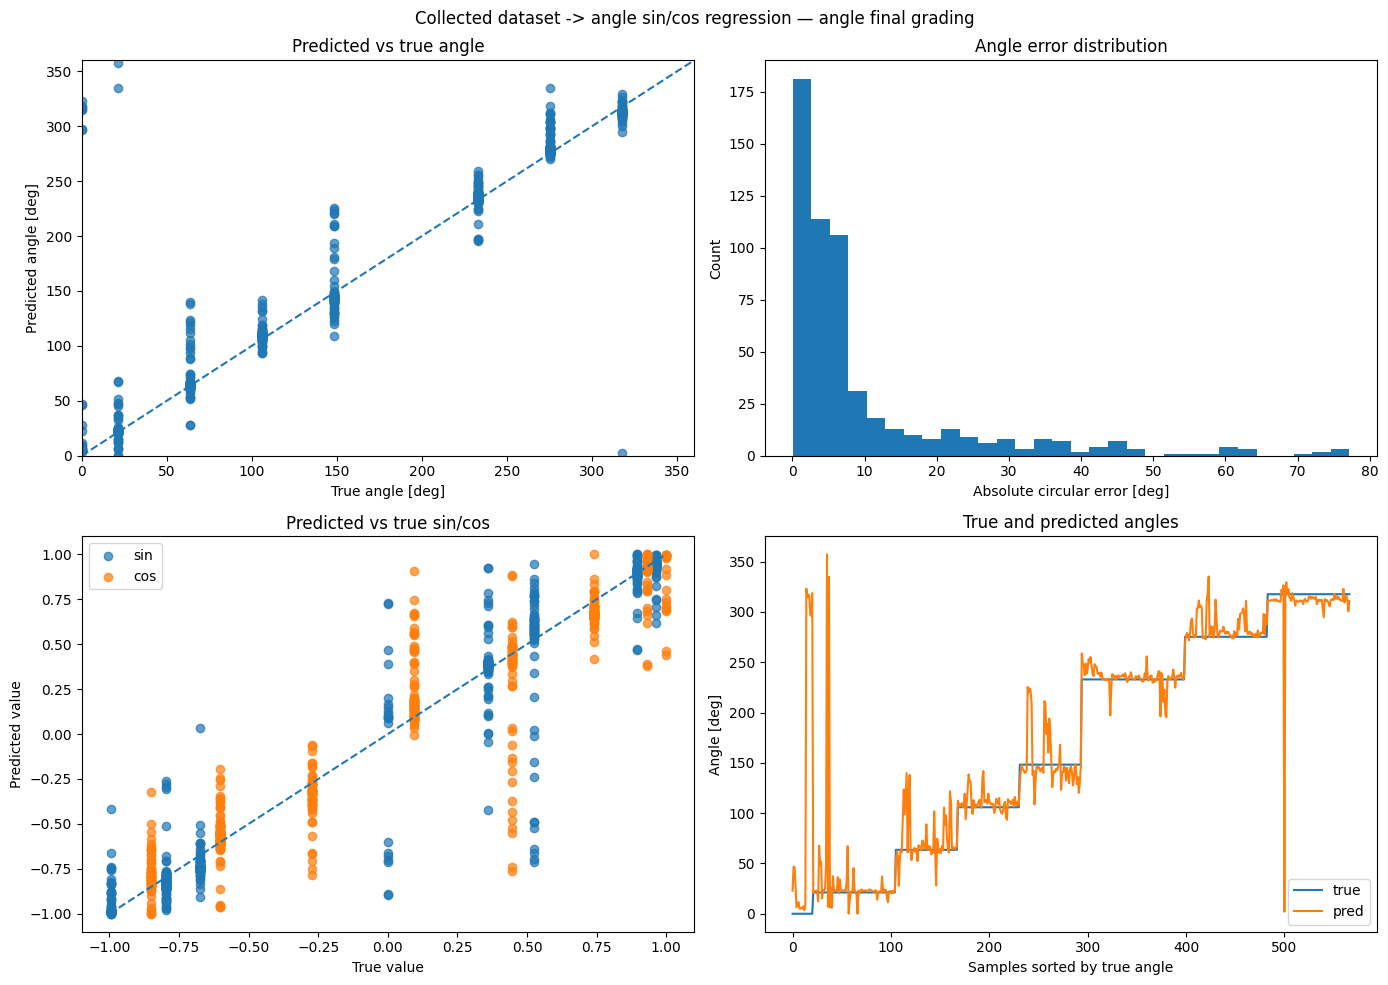

In [14]:
angle_collected_final_predictions, angle_collected_final_grade = display_model_grading(
    model_name="angle_collected",
    scope="angle",
    datasets=["collected"],
    predictions_df=globals().get("angle_collected_predictions"),
    metrics=globals().get("angle_collected_metrics"),
)


### Final grading — mass_collected


### mass_collected: final grading

,model,metric,value,unit
0,mass_collected,test_loss_best_model,0.003882,MSE
1,mass_collected,test_mass_mae_from_evaluate,0.046156,relative
2,mass_collected,mass_abs_error_mean,0.046156,relative
3,mass_collected,mass_abs_error_median,0.027751,relative
4,mass_collected,mass_abs_error_p95,0.135661,relative
5,mass_collected,mass_abs_error_max,0.300790,relative
6,mass_collected,mass_abs_error_mean,21.693110,g*mm
7,mass_collected,mass_abs_error_median,13.042955,g*mm
8,mass_collected,mass_abs_error_p95,63.760729,g*mm
9,mass_collected,mass_abs_error_max,141.371095,g*mm


### mass_collected: prediction table with computed errors

,sample_index,path,dataset,source_file,segment_idx,imbalance_actual_gmm,imbalance_relative,angle_deg,imbalance_relative_pred,imbalance_relative_true,true_value,pred_value,residual,abs_error,true_actual_gmm_from_relative,pred_actual_gmm_from_relative,residual_actual_gmm,abs_error_actual_gmm
0,0,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew2_processed.csv,0,261.0,0.555319,232.941176,0.650391,0.555319,0.555319,0.650391,0.095071,0.095071,260.999991,305.683594,44.683602,44.683602
1,1,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew2_processed.csv,1,261.0,0.555319,232.941176,0.610352,0.555319,0.555319,0.610352,0.055032,0.055032,260.999991,286.865234,25.865243,25.865243
2,2,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew2_processed.csv,2,261.0,0.555319,232.941176,0.654297,0.555319,0.555319,0.654297,0.098978,0.098978,260.999991,307.519531,46.519540,46.519540
3,3,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew2_processed.csv,3,261.0,0.555319,232.941176,0.675293,0.555319,0.555319,0.675293,0.119974,0.119974,260.999991,317.387695,56.387704,56.387704
4,4,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew2_processed.csv,4,261.0,0.555319,232.941176,0.673828,0.555319,0.555319,0.673828,0.118509,0.118509,260.999991,316.699219,55.699227,55.699227
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
856,856,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,2,470.0,1.000000,148.235294,0.961914,1.000000,1.000000,0.961914,-0.038086,0.038086,470.000000,452.099609,-17.900391,17.900391
857,857,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,3,470.0,1.000000,148.235294,0.932617,1.000000,1.000000,0.932617,-0.067383,0.067383,470.000000,438.330078,-31.669922,31.669922
858,858,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,4,470.0,1.000000,148.235294,0.948242,1.000000,1.000000,0.948242,-0.051758,0.051758,470.000000,445.673828,-24.326172,24.326172
859,859,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,5,470.0,1.000000,148.235294,0.976562,1.000000,1.000000,0.976562,-0.023438,0.023438,470.000000,458.984375,-11.015625,11.015625


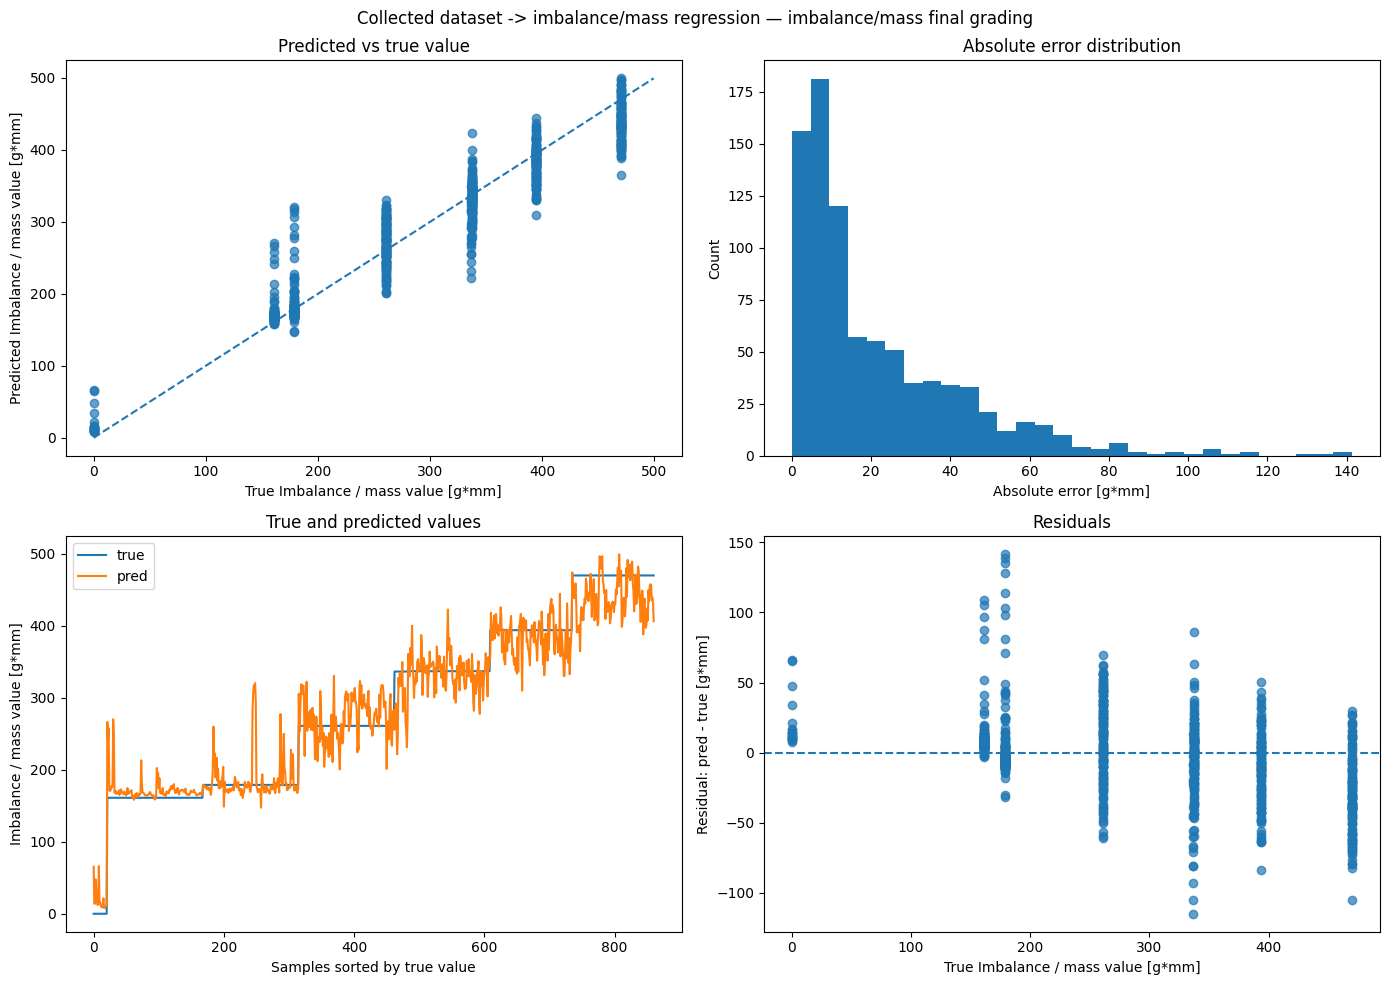

In [15]:
mass_collected_final_predictions, mass_collected_final_grade = display_model_grading(
    model_name="mass_collected",
    scope="mass",
    datasets=["collected"],
    predictions_df=globals().get("mass_collected_predictions"),
    metrics=globals().get("mass_collected_metrics"),
)


### Final grading — mass_public


### mass_public: final grading

,model,metric,value,unit
0,mass_public,test_loss_best_model,0.027194,MSE
1,mass_public,test_mass_mae_from_evaluate,0.127721,relative
2,mass_public,mass_abs_error_mean,0.127721,relative
3,mass_public,mass_abs_error_median,0.107523,relative
4,mass_public,mass_abs_error_p95,0.327185,relative
5,mass_public,mass_abs_error_max,0.515189,relative
6,mass_public,mass_abs_error_mean,670.535030,g*mm
7,mass_public,mass_abs_error_median,564.495837,g*mm
8,mass_public,mass_abs_error_p95,1717.721558,g*mm
9,mass_public,mass_abs_error_max,2704.742521,g*mm


### mass_public: prediction table with computed errors

,sample_index,path,dataset,source_file,segment_idx,imbalance_actual_gmm,imbalance_relative,angle_deg,imbalance_relative_pred,imbalance_relative_true,true_value,pred_value,residual,abs_error,true_actual_gmm_from_relative,pred_actual_gmm_from_relative,residual_actual_gmm,abs_error_actual_gmm
0,0,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,12.288.csv,0,0.0,0.000000,0.0,0.255127,0.000000,0.000000,0.255127,0.255127,0.255127,0.000000,1339.416504,1339.416504,1339.416504
1,1,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,12.288.csv,1,0.0,0.000000,0.0,0.172729,0.000000,0.000000,0.172729,0.172729,0.172729,0.000000,906.829834,906.829834,906.829834
2,2,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,13.1072.csv,0,0.0,0.000000,0.0,0.311279,0.000000,0.000000,0.311279,0.311279,0.311279,0.000000,1634.216309,1634.216309,1634.216309
3,3,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,13.1072.csv,1,0.0,0.000000,0.0,0.263916,0.000000,0.000000,0.263916,0.263916,0.263916,0.000000,1385.559082,1385.559082,1385.559082
4,4,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,14.336.csv,0,0.0,0.000000,0.0,0.298584,0.000000,0.000000,0.298584,0.298584,0.298584,0.000000,1567.565918,1567.565918,1567.565918
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
149,149,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,54.4768.csv,1,900.0,0.171429,0.0,0.182739,0.171429,0.171429,0.182739,0.011311,0.011311,900.000025,959.381104,59.381079,59.381079
150,150,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,55.296.csv,0,900.0,0.171429,0.0,0.204102,0.171429,0.171429,0.204102,0.032673,0.032673,900.000025,1071.533203,171.533179,171.533179
151,151,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,55.296.csv,1,900.0,0.171429,0.0,0.174561,0.171429,0.171429,0.174561,0.003132,0.003132,900.000025,916.442871,16.442847,16.442847
152,152,c:\Users\szymo\Desktop\Wibracje\data_preproces...,public,58.1632.csv,0,900.0,0.171429,0.0,0.183105,0.171429,0.171429,0.183105,0.011677,0.011677,900.000025,961.303711,61.303686,61.303686


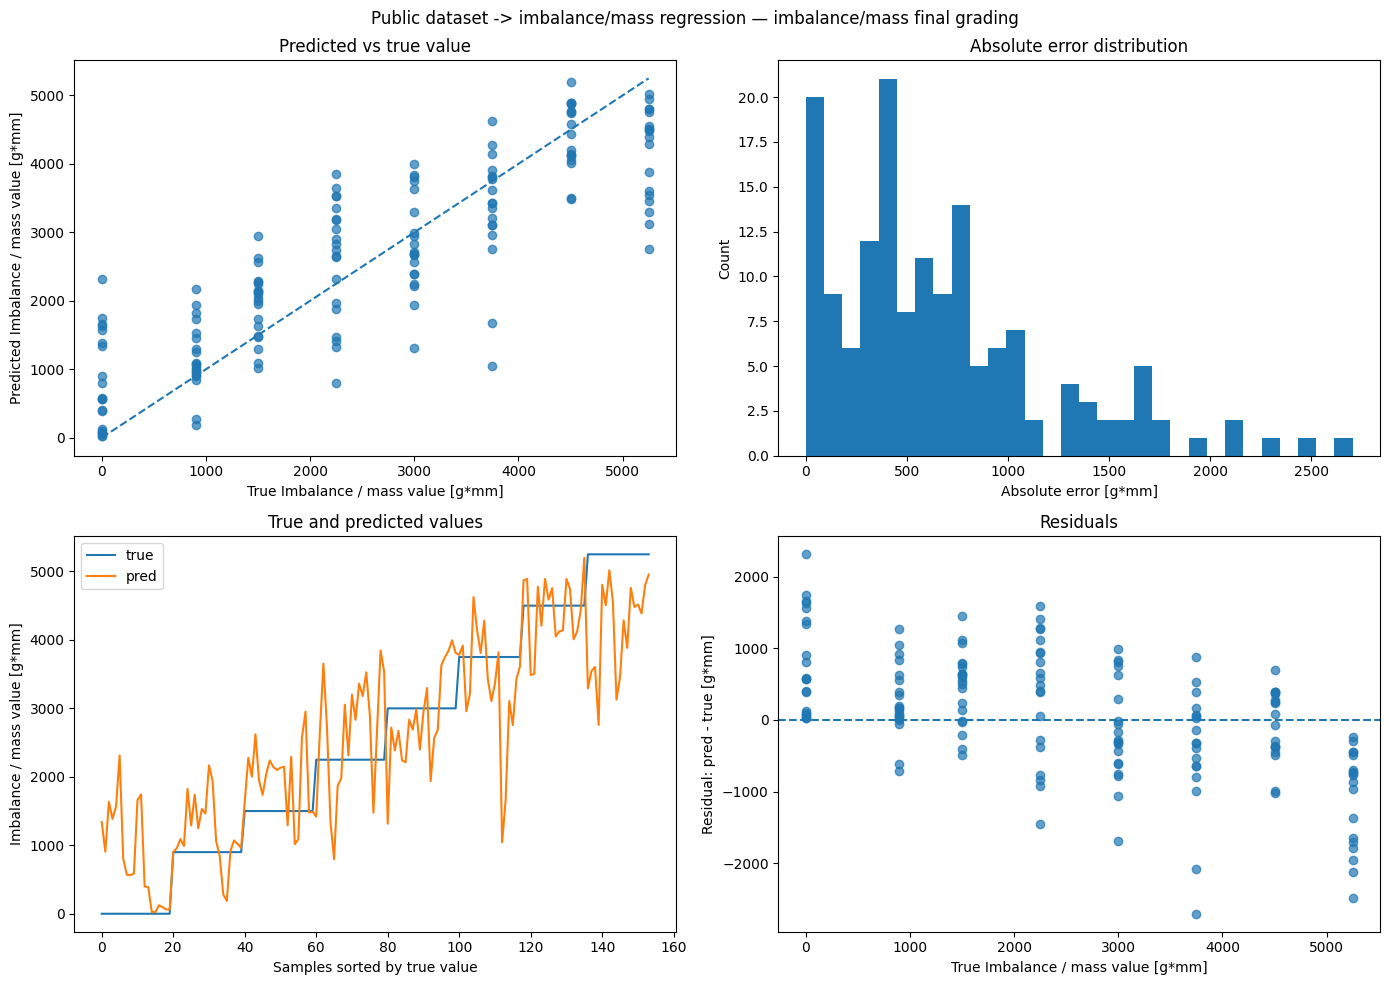

In [16]:
mass_public_final_predictions, mass_public_final_grade = display_model_grading(
    model_name="mass_public",
    scope="mass",
    datasets=["public"],
    predictions_df=globals().get("mass_public_predictions"),
    metrics=globals().get("mass_public_metrics"),
)


### Final grading — angle_mass_collected


### angle_mass_collected: final grading

,model,metric,value,unit
0,angle_mass_collected,test_loss_best_model,0.048174,MSE
1,angle_mass_collected,test_angle_mae_from_evaluate,10.587254,deg
2,angle_mass_collected,test_mass_mae_from_evaluate,0.084861,relative
3,angle_mass_collected,angle_abs_error_mean,10.587253,deg
4,angle_mass_collected,angle_abs_error_median,5.536662,deg
5,angle_mass_collected,angle_abs_error_p95,37.797545,deg
6,angle_mass_collected,angle_abs_error_max,121.433746,deg
7,angle_mass_collected,mass_abs_error_mean,0.084861,relative
8,angle_mass_collected,mass_abs_error_median,0.065205,relative
9,angle_mass_collected,mass_abs_error_p95,0.232072,relative


### angle_mass_collected: prediction table with computed errors

,sample_index,path,dataset,source_file,segment_idx,imbalance_actual_gmm,imbalance_relative,angle_deg,angle_pred_deg,angle_true_deg,...,pred_sin,pred_cos,true_value,pred_value,residual,abs_error,true_actual_gmm_from_relative,pred_actual_gmm_from_relative,residual_actual_gmm,abs_error_actual_gmm
0,0,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,0,179.0,0.380851,232.941176,216.198502,232.941176,...,-0.590585,-0.806976,0.380851,0.582520,0.201668,0.201668,178.999998,273.784180,94.784181,94.784181
1,1,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,1,179.0,0.380851,232.941176,224.750458,232.941176,...,-0.704020,-0.710180,0.380851,0.552734,0.171883,0.171883,178.999998,259.785156,80.785158,80.785158
2,2,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,2,179.0,0.380851,232.941176,223.404495,232.941176,...,-0.687145,-0.726521,0.380851,0.507812,0.126961,0.126961,178.999998,238.671875,59.671877,59.671877
3,3,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,3,179.0,0.380851,232.941176,221.622894,232.941176,...,-0.664225,-0.747533,0.380851,0.483887,0.103036,0.103036,178.999998,227.426758,48.426760,48.426760
4,4,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v01_14_a11_zew_processed.csv,4,179.0,0.380851,232.941176,218.609879,232.941176,...,-0.624014,-0.781413,0.380851,0.529785,0.148934,0.148934,178.999998,248.999023,69.999025,69.999025
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
562,562,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,2,470.0,1.000000,148.235294,152.767578,148.235294,...,0.457601,-0.889158,1.000000,0.936523,-0.063477,0.063477,470.000000,440.166016,-29.833984,29.833984
563,563,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,3,470.0,1.000000,148.235294,137.156555,148.235294,...,0.679997,-0.733214,1.000000,0.991211,-0.008789,0.008789,470.000000,465.869141,-4.130859,4.130859
564,564,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,4,470.0,1.000000,148.235294,128.563263,148.235294,...,0.781920,-0.623378,1.000000,0.968750,-0.031250,0.031250,470.000000,455.312500,-14.687500,14.687500
565,565,c:\Users\szymo\Desktop\Wibracje\data_preproces...,collected,v14_14_a7_zewd3_processed.csv,5,470.0,1.000000,148.235294,136.177124,148.235294,...,0.692431,-0.721484,1.000000,1.002930,0.002930,0.002930,470.000000,471.376953,1.376953,1.376953


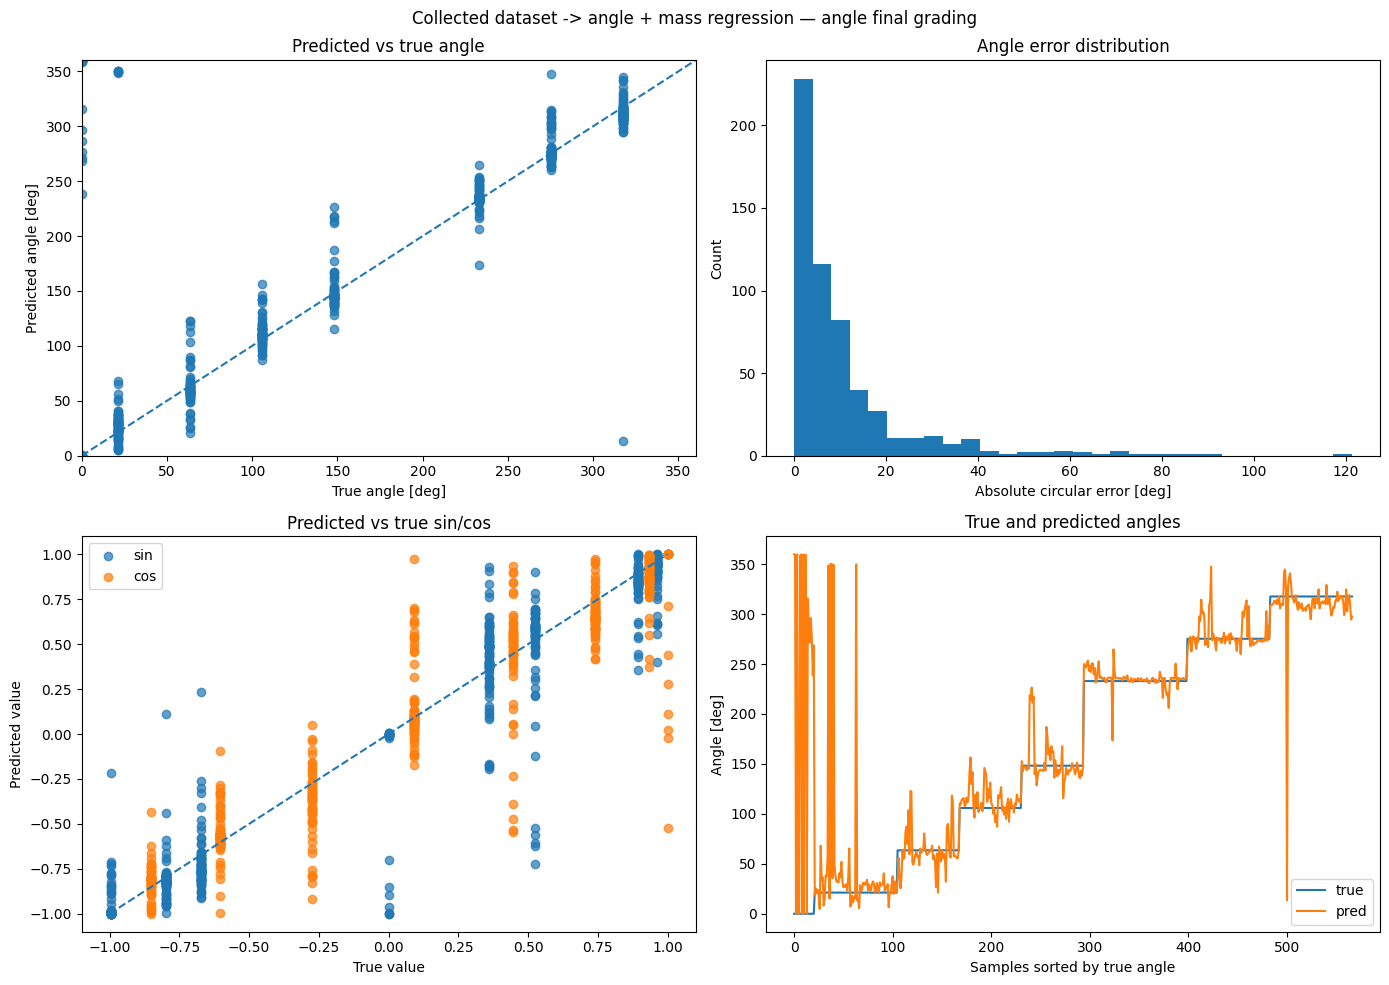

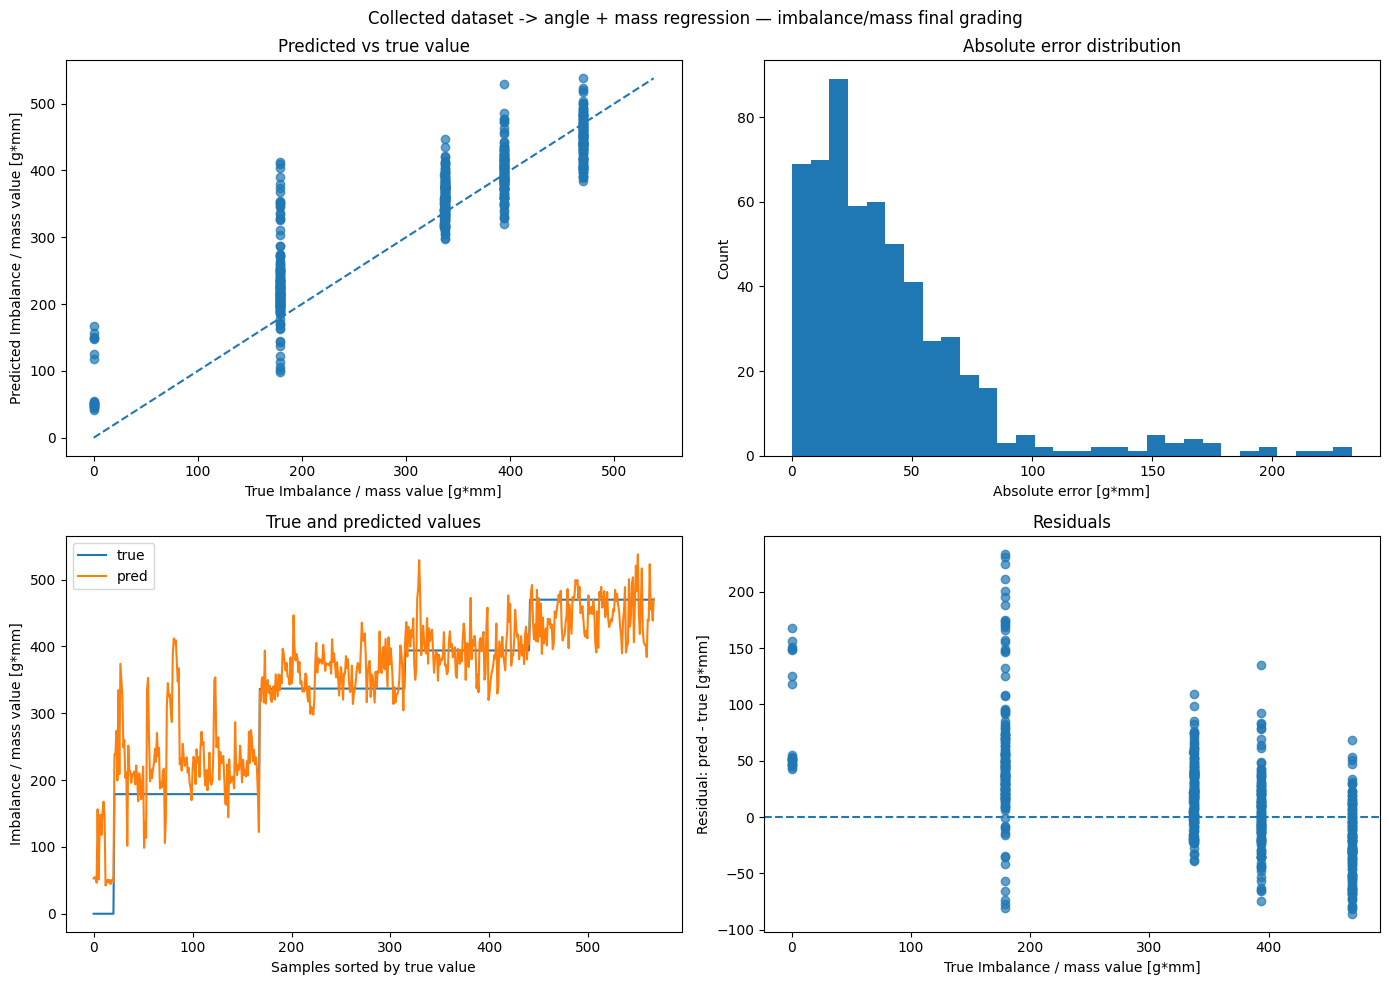

In [17]:
angle_mass_collected_final_predictions, angle_mass_collected_final_grade = display_model_grading(
    model_name="angle_mass_collected",
    scope="both",
    datasets=["collected"],
    predictions_df=globals().get("angle_mass_collected_predictions"),
    metrics=globals().get("angle_mass_collected_metrics"),
)


### Final grading summary


In [18]:
all_model_final_grades = pd.concat(
    [
        angle_collected_final_grade,
        mass_collected_final_grade,
        mass_public_final_grade,
        angle_mass_collected_final_grade,
    ],
    ignore_index=True,
)

display(Markdown("### All model final grades"))
display(all_model_final_grades)

summary_path = MODEL_ROOT / "additional_data" / "all_model_final_grades.csv"
summary_path.parent.mkdir(parents=True, exist_ok=True)
all_model_final_grades.to_csv(summary_path, index=False)
print("Saved:", summary_path)


### All model final grades

,model,metric,value,unit
0,angle_collected,test_loss_best_model,0.034929,MSE
1,angle_collected,test_angle_mae_from_evaluate,9.905585,deg
2,angle_collected,angle_abs_error_mean,9.905588,deg
3,angle_collected,angle_abs_error_median,4.855602,deg
4,angle_collected,angle_abs_error_p95,41.750969,deg
5,angle_collected,angle_abs_error_max,77.169033,deg
6,mass_collected,test_loss_best_model,0.003882,MSE
7,mass_collected,test_mass_mae_from_evaluate,0.046156,relative
8,mass_collected,mass_abs_error_mean,0.046156,relative
9,mass_collected,mass_abs_error_median,0.027751,relative


Saved: c:\Users\szymo\Desktop\Wibracje\Modele\Unified\Models\unified_example_full_with_subtraction_500Hz_larger_larger_larger_longer_train\additional_data\all_model_final_grades.csv
